# **Student Academic Performance Prediction Using Machine Learning**

Data Cleaning--Data Visualization--Data Preprocessing--Build Models

Models:

1.Supervised Learning Classification Models

**Logistic Regression,** **Decision Tree, Random Forest,**

KNN,Perceptron, Support Vector Classifier, Gaussian Naive Bayes, Multi-Layer Perceptron

2.Unsupervised Learning Clustering Models (Exploring data grouping is not for the purpose of outputting accuracy)

Agglomerative Clustering, KMeans


PS: PCA was not used because the feature dimension was not high and interpretability needed to be retained.

## Reproducibility Note
This repository version loads data using a relative path and uses fixed random seeds where applicable. The analysis follows the original project methodology and reports 5-fold cross-validation results.


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the dataset from the repository's data folder
from pathlib import Path

candidate_paths = [
    Path('../data/student_data.csv'),  # when running from notebooks/
    Path('data/student_data.csv'),     # when running from repository root
    Path('student_data.csv')           # fallback
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('student_data.csv not found. Run the notebook from the repository root or notebooks folder.')

df = pd.read_csv(data_path)
print(f'Loaded {df.shape[0]} rows and {df.shape[1]} columns from {data_path}')


In [ ]:
# Preview the dataset
df.head()


# **Data Cleaning**

In [46]:
# Check the data type of each column and missing values (non-null count)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

# **Data Visualization**

In [47]:
# Convert G3/label_y into pass_fail
df['pass_fail'] = df['G3/label_y'].apply(lambda x: 1 if x >= 12 else 0)
df.drop(columns=['G3/label_y'], inplace=True)
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2 pass_fail  
0      4        3      4     1     1      3        6   5   6         0  
1      5        3      3     1     1      3        4   5   5         0  
2      4        3      2     2     3      3       10   7   8         0  
3      3        2      2     1     1      5        2  15  14         1  
4      4        3      2     1     2      5        4   6  10         0  

[5 rows x 33 columns]


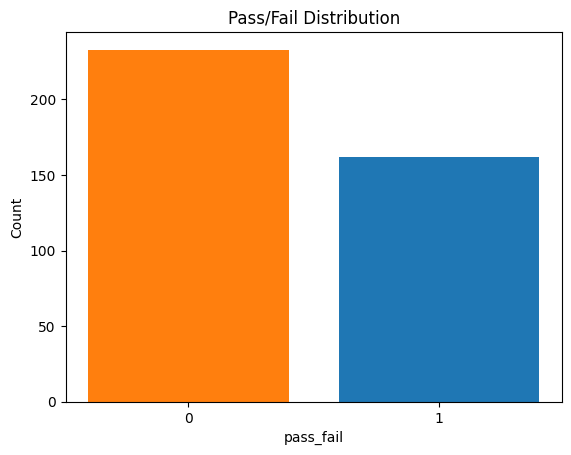

In [48]:
# Use a bar chart to visualize the distribution of the target variable pass_fail
# and observe whether the classes are balanced.

counts = df['pass_fail'].value_counts().sort_index()

plt.bar(counts.index, counts.values, color=['#ff7f0e', '#1f77b4'])

plt.title('Pass/Fail Distribution')
plt.xlabel('pass_fail')
plt.ylabel('Count')

plt.xticks([0, 1])

plt.show()

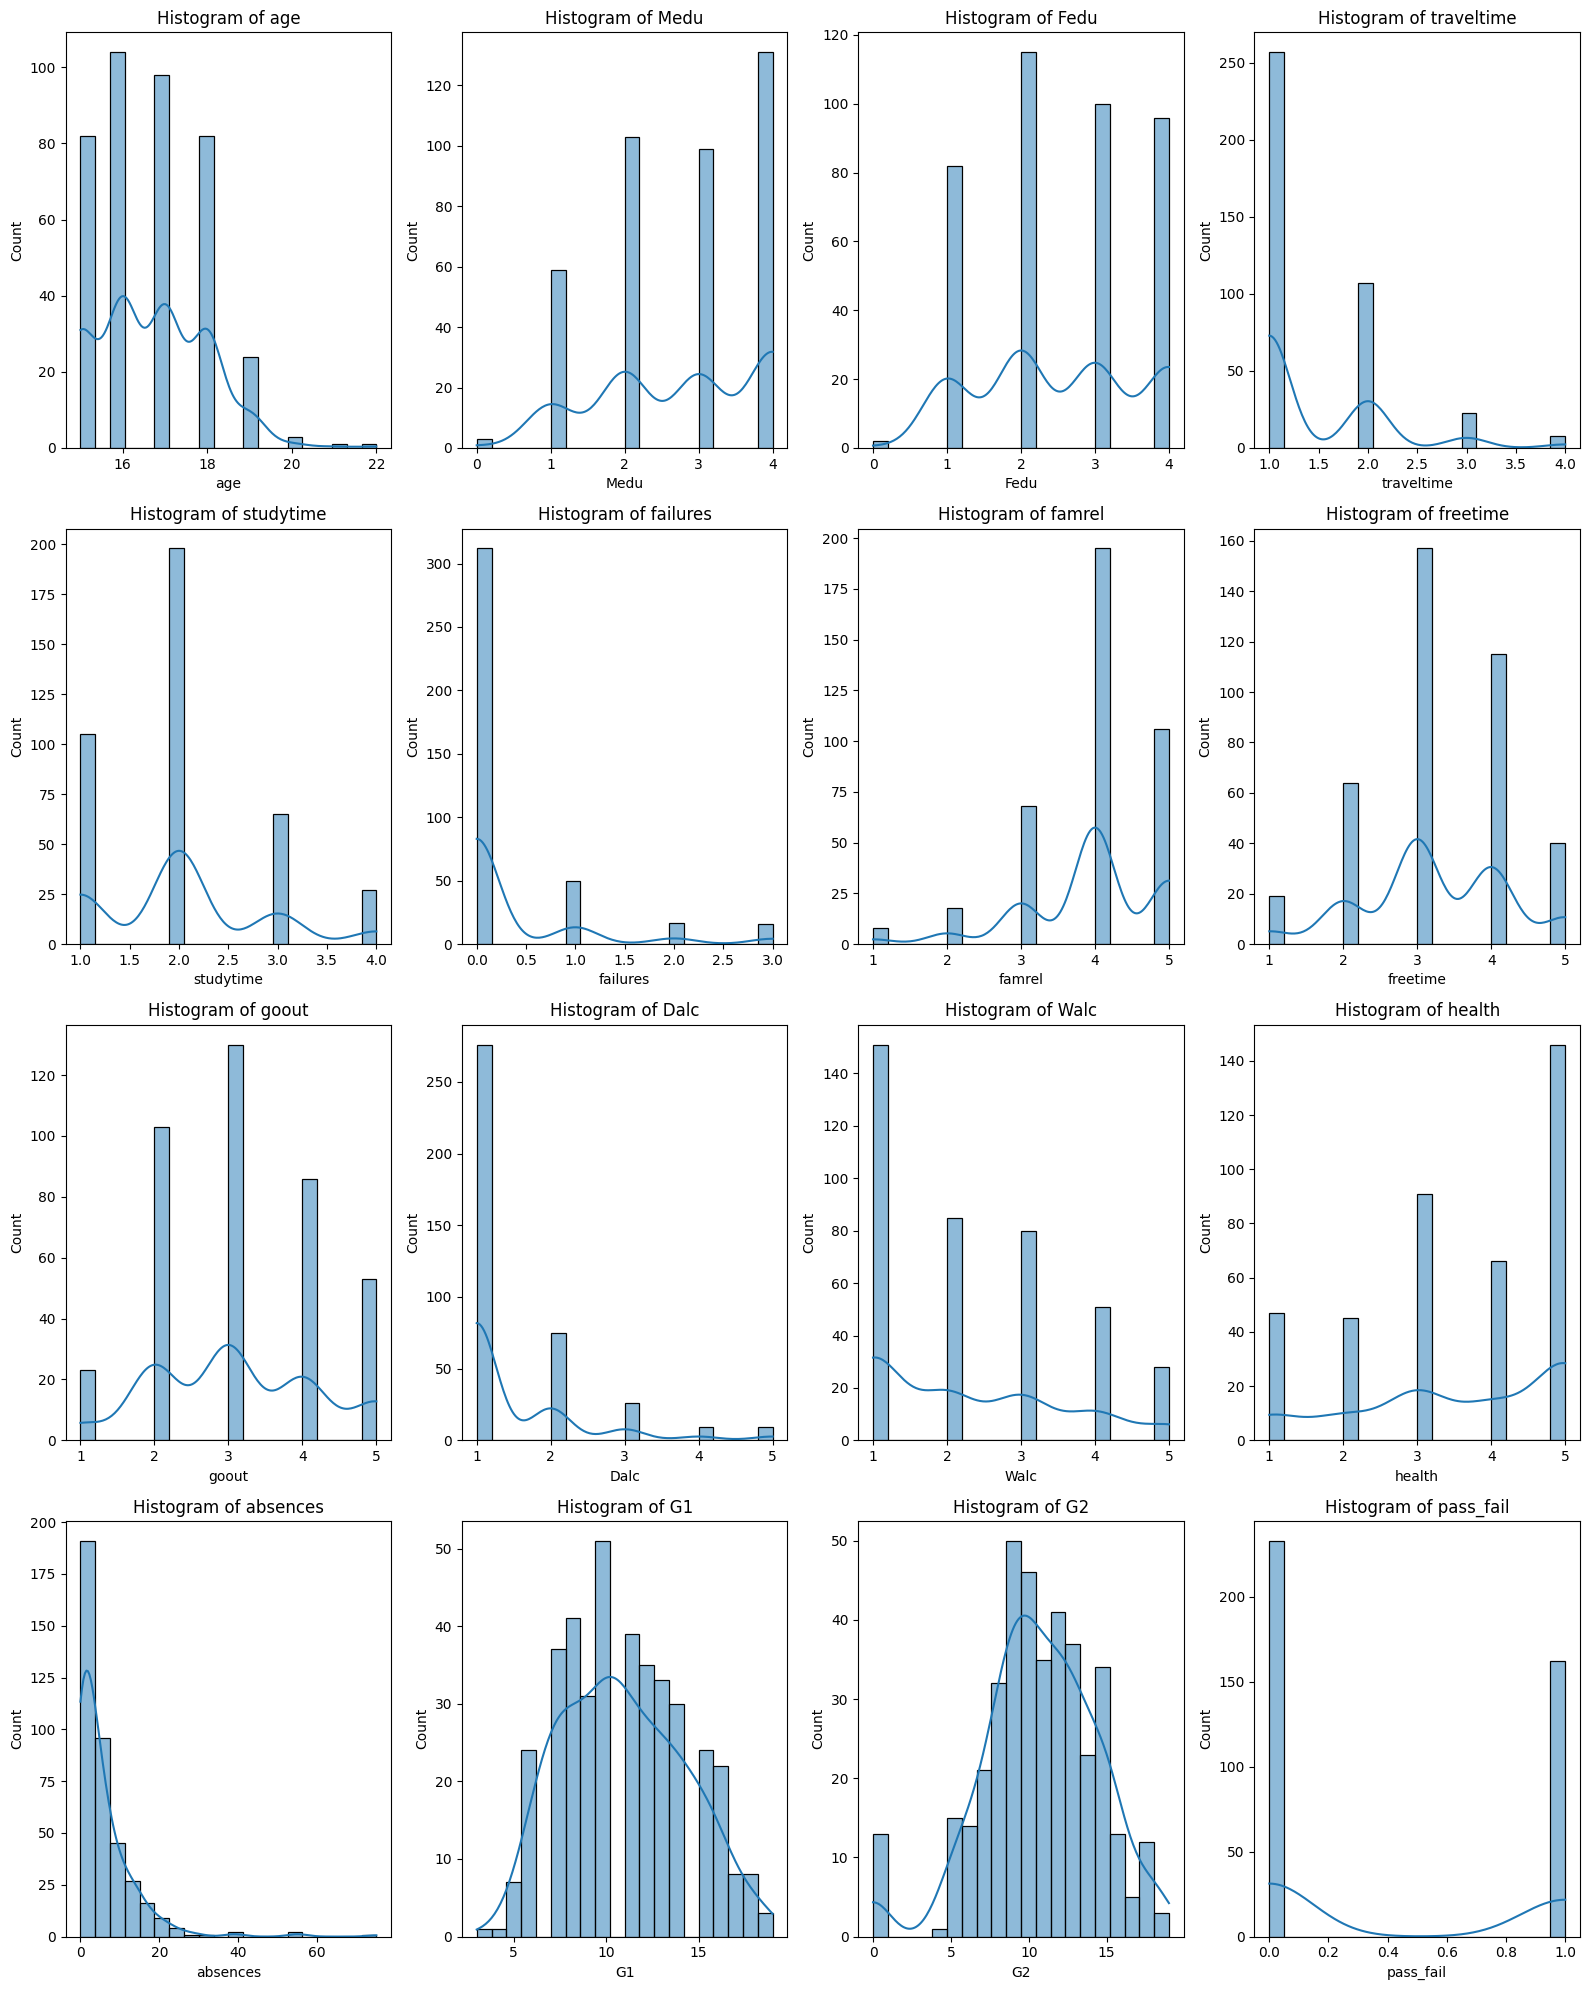

In [49]:
# Use histograms and KDE curves to visualize the distribution of each numerical variable
# and observe their distribution patterns.

numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(16, 20))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i) # Changed from 5, 3 to 4, 4 to accommodate 16 columns
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

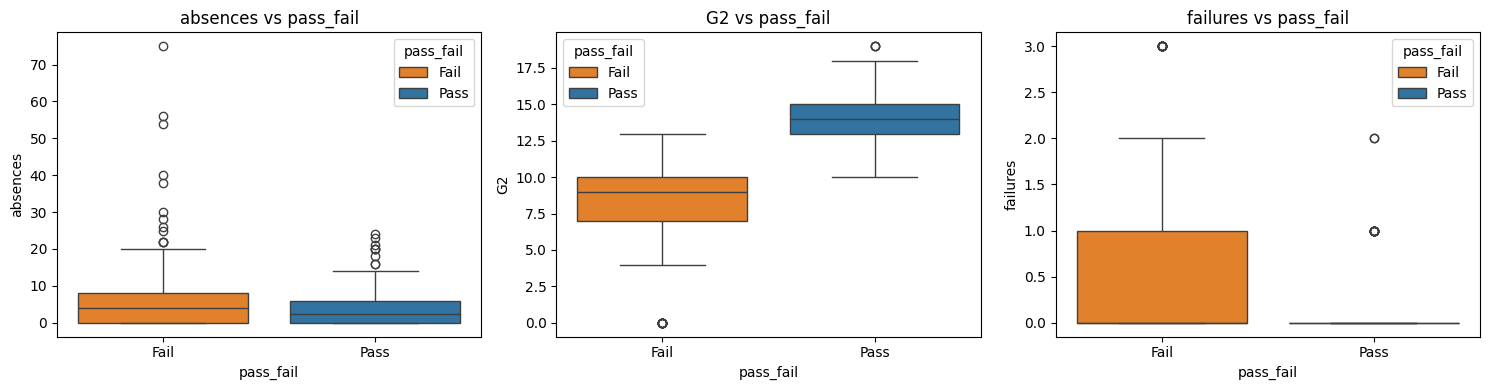

In [50]:
# Use boxplots to visualize the distribution differences of G1, G2, and absences across different pass_fail categories,
# in order to observe the relationships between these features and pass/fail outcomes.

selected_cols = ['absences', 'G2', 'failures']
plt.figure(figsize=(15, 4))

palette = ['#ff7f0e', '#1f77b4']

for i, col in enumerate(selected_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='pass_fail', y=col, data=df, hue=df['pass_fail'].map({0: 'Fail', 1: 'Pass'}), palette=palette)
    plt.title(f'{col} vs pass_fail')
    plt.xticks([0, 1], ['Fail', 'Pass'])

plt.tight_layout()
plt.show()

# **Data Preprocessing**

# **Outliers Detection**

In [51]:
# check for outliers in each feature
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df[numeric_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()

,0
age,1
Medu,0
Fedu,2
traveltime,8
studytime,27
failures,83
famrel,26
freetime,19
goout,0
Dalc,18


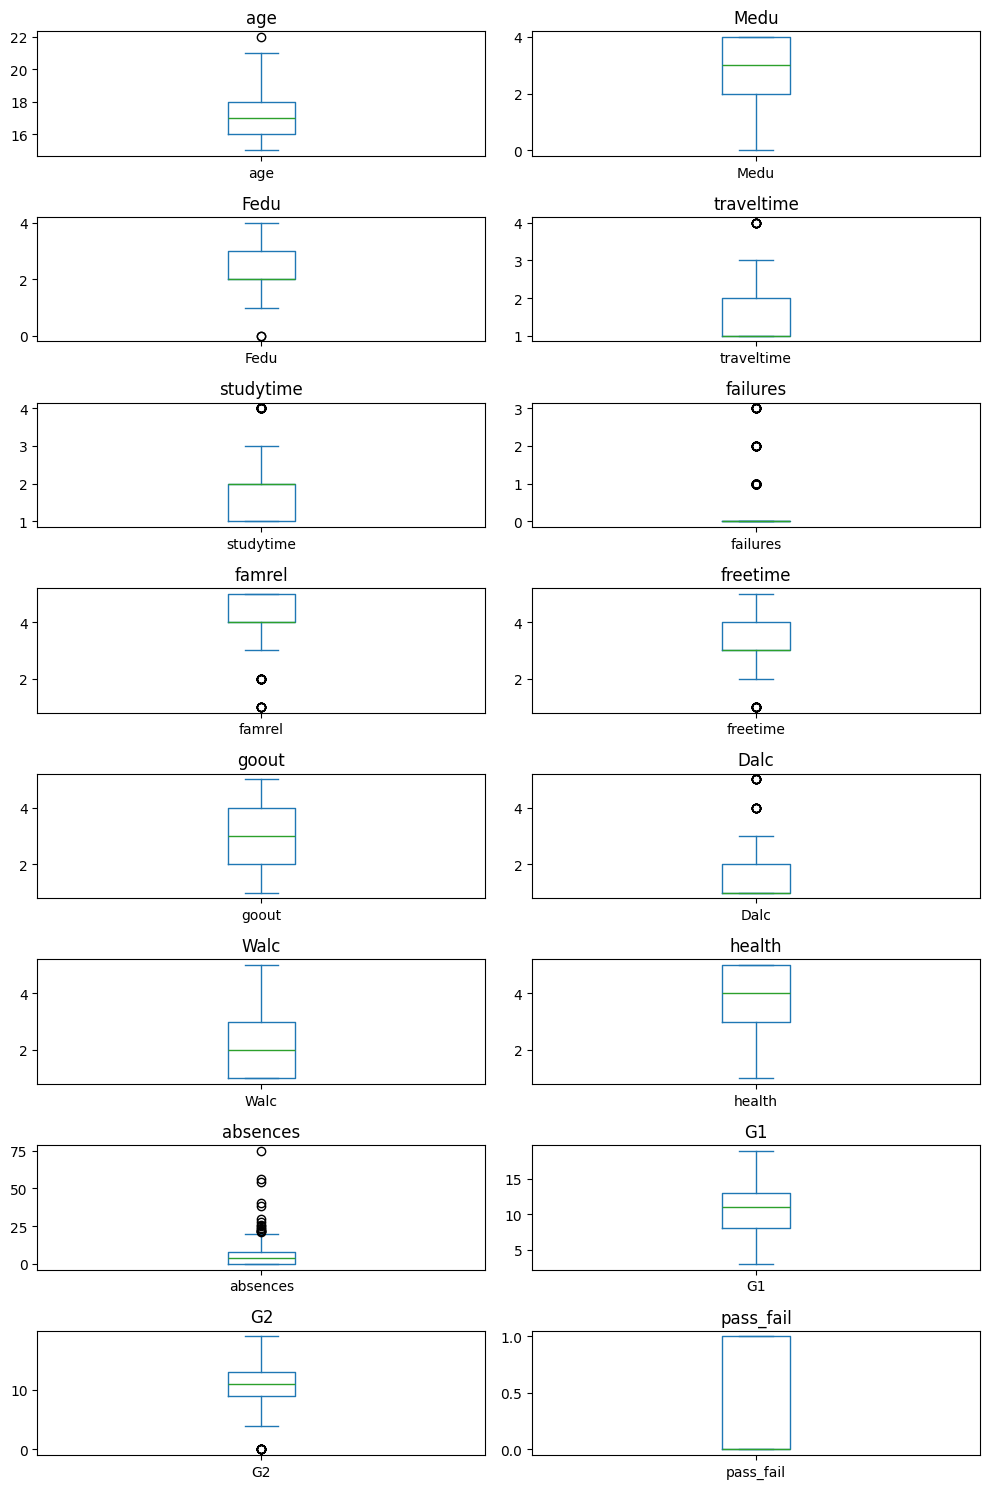

In [52]:
# Use box plots to visualize the distribution of each numerical variable
# and observe their spread and potential outliers.

fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].plot(kind='box', ax=axes[i], title=col)

plt.tight_layout()
plt.show()

Outliers in this dataset represent real student behavior (e.g., high absences, low grades), not data errors. Tree-based models handle them well, and scaling stabilizes KNN, so removing or capping outliers would lose important predictive information.

# **Apply one-hot encoding to categorical text variables**

In [53]:
# Use select_dtypes() and nunique() to count the number of unique values in each object-type column,
# in order to identify categorical text features and their category counts.

object_cols = df.select_dtypes(include=['object']).columns

unique_summary = pd.DataFrame({
    'column': object_cols,
    'unique_count': [df[col].nunique() for col in object_cols]
})

print(unique_summary)

        column  unique_count
0       school             2
1          sex             2
2      address             2
3      famsize             2
4      Pstatus             2
5         Mjob             5
6         Fjob             5
7       reason             4
8     guardian             3
9    schoolsup             2
10      famsup             2
11        paid             2
12  activities             2
13     nursery             2
14      higher             2
15    internet             2
16    romantic             2


In [54]:
# Use pd.get_dummies() to apply one-hot encoding to all categorical text variables and generate an encoding summary table,
# in order to convert categorical features into numerical form and clearly show the meaning of each encoded variable.

# Select all object-type columns except 'school'
text_cols = [col for col in object_cols]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=text_cols, drop_first=True, dtype=int)

# Build a clearer encoding table
mapping_summary = []

for col in text_cols:
    original_values = sorted(df[col].dropna().unique())
    encoded_cols = [c for c in df_encoded.columns if c.startswith(col + "_")]

    encoded_values = [c.replace(col + "_", "") for c in encoded_cols]
    dropped_values = [v for v in original_values if v not in encoded_values]

    # If the variable has only 2 categories and only 1 encoded column,
    # then 0 means the dropped category and 1 means the kept category
    if len(original_values) == 2 and len(encoded_cols) == 1:
        mapping_summary.append({
            'encoded_column': encoded_cols[0],
            '0 means': dropped_values[0],
            '1 means': encoded_values[0]
        })
    else:
        # For multi-category variables, each encoded column means:
        # 1 = belongs to this category
        # 0 = does not belong to this category
        for enc_col, enc_val in zip(encoded_cols, encoded_values):
            mapping_summary.append({
                'encoded_column': enc_col,
                '0 means': f"not {enc_val}",
                '1 means': enc_val
            })

mapping_df = pd.DataFrame(mapping_summary)

print("Encoding summary table:")
print(mapping_df)

print("\nEncoded DataFrame info:")
print(df_encoded.info())

Encoding summary table:
       encoded_column         0 means     1 means
0           school_MS              GP          MS
1               sex_M               F           M
2           address_U               R           U
3         famsize_LE3             GT3         LE3
4           Pstatus_T               A           T
5         Mjob_health      not health      health
6          Mjob_other       not other       other
7       Mjob_services    not services    services
8        Mjob_teacher     not teacher     teacher
9         Fjob_health      not health      health
10         Fjob_other       not other       other
11      Fjob_services    not services    services
12       Fjob_teacher     not teacher     teacher
13        reason_home        not home        home
14       reason_other       not other       other
15  reason_reputation  not reputation  reputation
16    guardian_mother      not mother      mother
17     guardian_other       not other       other
18      schoolsup_yes     

In [55]:
import pandas as pd

# Let pandas display full column content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# Show only original variable name and its new encoded columns
summary_rows = []

for col in text_cols:
    encoded_cols = [c for c in df_encoded.columns if c.startswith(col + "_")]

    summary_rows.append({
        "Variable": col,
        "New Columns": "; ".join(encoded_cols)
    })

summary_table = pd.DataFrame(summary_rows)

print("One-hot encoding summary:")
print(summary_table.to_string(index=False))

One-hot encoding summary:
  Variable                                          New Columns
    school                                            school_MS
       sex                                                sex_M
   address                                            address_U
   famsize                                          famsize_LE3
   Pstatus                                            Pstatus_T
      Mjob Mjob_health; Mjob_other; Mjob_services; Mjob_teacher
      Fjob Fjob_health; Fjob_other; Fjob_services; Fjob_teacher
    reason         reason_home; reason_other; reason_reputation
  guardian                      guardian_mother; guardian_other
 schoolsup                                        schoolsup_yes
    famsup                                           famsup_yes
      paid                                             paid_yes
activities                                       activities_yes
   nursery                                          nursery_yes
    higher    

# **Feature/Target and Cross-Validation Setup**

This section defines the input features (X) and the target variable (y) used for prediction. A 5-fold cross-validation strategy is applied to ensure reliable and unbiased model evaluation, the dataset is split into five parts, and each part is used once as a test set. Multiple performance metrics: accuracy, precision, recall, and F1-score—are used to provide a comprehensive assessment of model performance.

In [56]:
from sklearn.model_selection import cross_validate, KFold

# Define the features (attributes) and the target (label)
X = df_encoded.drop(columns=['pass_fail'])   # Features
y = df_encoded['pass_fail']                  # Target (label)

# Set up 5-fold cross-validation with shuffling
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform 5-fold cross-validation and get scores for each fold
scoring = ['accuracy', 'precision', 'recall', 'f1']

# **Build Models**

# **Logistic Regression**

The scaler standardizes features so that different variables are placed on a similar scale, which improves the stability and performance of Logistic Regression. The Pipeline connects preprocessing and model training steps, ensuring they are executed in the correct order, and during cross-validation it fits the scaler only on the training portion of each fold, thereby preventing data leakage.

In [57]:
# Use a Pipeline with StandardScaler and 5-fold cross-validation to train and evaluate the Logistic Regression model,
# in order to measure its Accuracy, Precision, Recall, and F1 Score in the classification task.

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

# Create a pipeline: scaling + logistic regression
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# Perform 5-fold cross-validation and get scores for each fold
cv_results = cross_validate(logreg_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Extract the metrics for each fold
accuracy_scores = cv_results['test_accuracy']
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']

# Save Logistic Regression accuracy scores for model comparison
logreg_acc = accuracy_scores

# Display the scores for each fold
print("Accuracy scores for each fold:", accuracy_scores)
print("Precision scores for each fold:", precision_scores)
print("Recall scores for each fold:", recall_scores)
print("F1 scores for each fold:", f1_scores)

Accuracy scores for each fold: [0.87341772 0.89873418 0.84810127 0.87341772 0.92405063]
Precision scores for each fold: [0.90625    0.85714286 0.80645161 0.89189189 0.86666667]
Recall scores for each fold: [0.80555556 0.85714286 0.80645161 0.84615385 0.92857143]
F1 scores for each fold: [0.85294118 0.85714286 0.80645161 0.86842105 0.89655172]


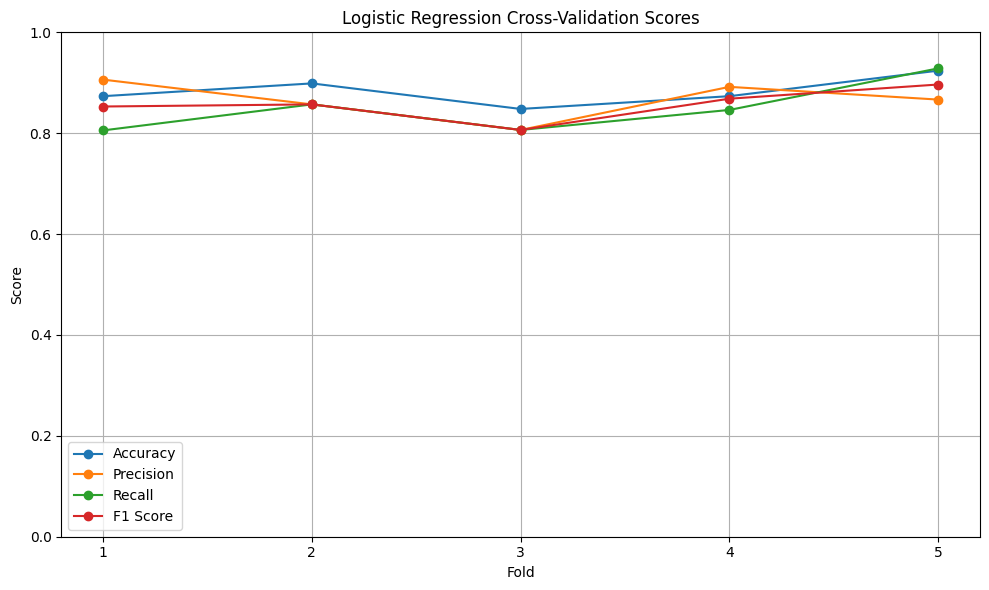

In [58]:
# Use a line chart to visualize the Accuracy, Precision, Recall, and F1 Score of Logistic Regression across cross-validation folds,
# in order to observe model performance and metric trends across different folds.

metrics = {
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
}

plt.figure(figsize=(10, 6))

for name, scores in metrics.items():
    plt.plot(range(1, len(scores)+1), scores, marker='o', label=name)

plt.xticks(range(1, len(accuracy_scores)+1))
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Logistic Regression Cross-Validation Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

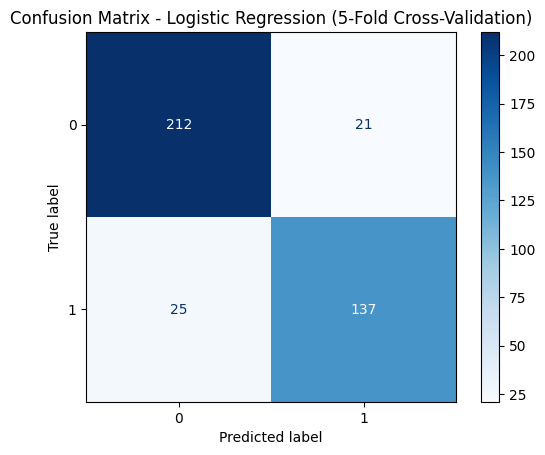

In [59]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get cross-validated predictions for Logistic Regression
y_pred_logreg = cross_val_predict(logreg_pipeline, X, y, cv=cv)

# Generate confusion matrix
cm_logreg = confusion_matrix(y, y_pred_logreg)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=[0, 1])

# Plot confusion matrix
disp_logreg.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (5-Fold Cross-Validation)')
plt.show()

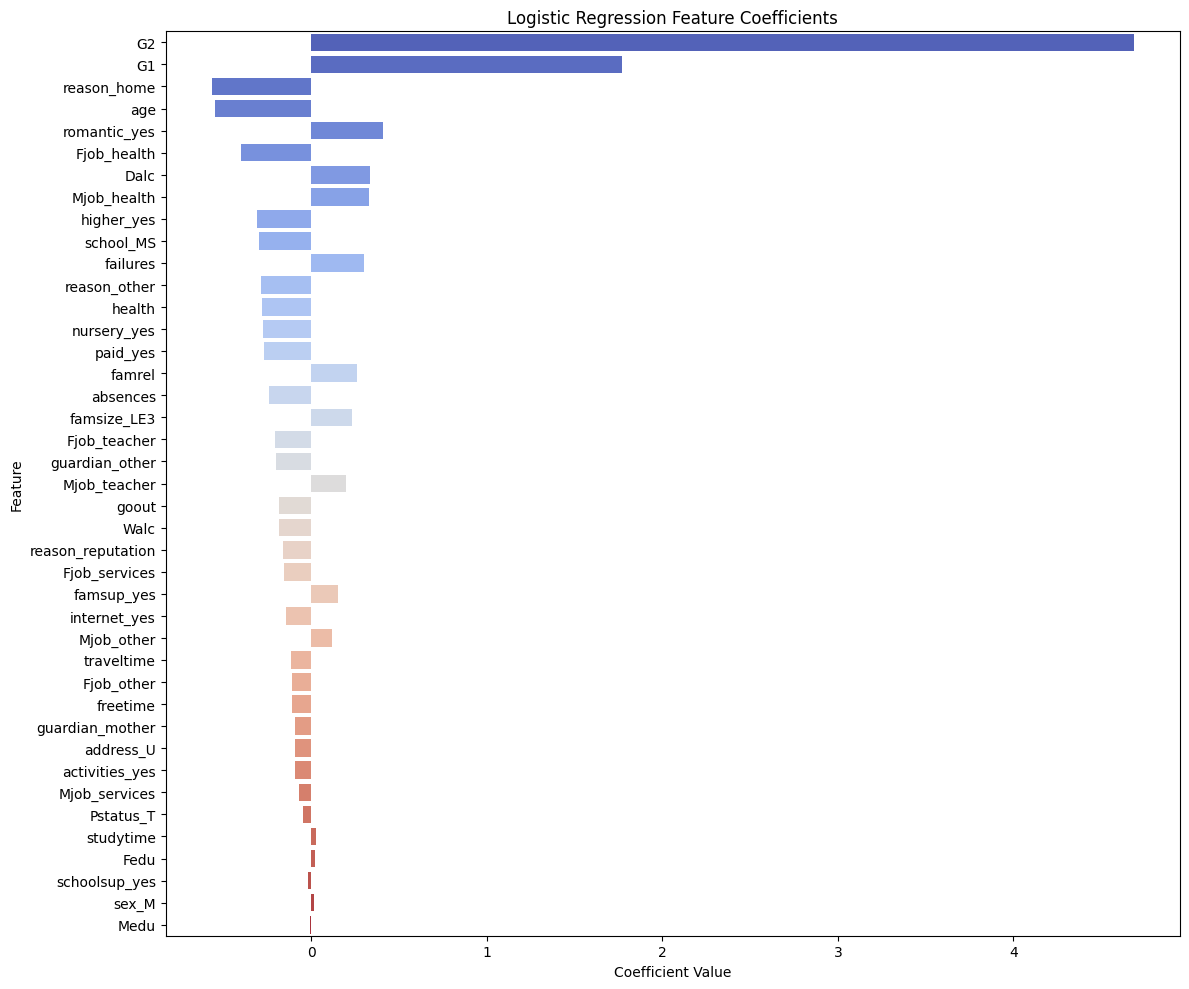

In [60]:
# Use a bar chart to visualize the feature coefficients of Logistic Regression
# in order to examine the direction and relative magnitude of each feature’s influence on the classification outcome.

# Fit the pipeline on the full encoded dataset
logreg_pipeline.fit(X, y)

# Get coefficients from the Logistic Regression model inside the pipeline
coefficients = logreg_pipeline.named_steps['model'].coef_[0]

# Create a Series with feature names
feature_coefficients = pd.Series(coefficients, index=X.columns)

# Sort coefficients by absolute value
sorted_coefficients = feature_coefficients.reindex(
    feature_coefficients.abs().sort_values(ascending=False).index
)

# Plot feature coefficients
plt.figure(figsize=(12, 10))
sns.barplot(
    x=sorted_coefficients.values,
    y=sorted_coefficients.index,
    hue=sorted_coefficients.index,
    palette='coolwarm',
    legend=False
)

plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# **Decision Tree**

For Decision Tree and Random Forest, scaling is generally not necessary because these models split data based on feature thresholds rather than distances or gradient-based optimization, so they are usually not sensitive to feature scale.

In [61]:
# Use 5-fold cross-validation to train and evaluate the Decision Tree model,
# in order to measure its Accuracy, Precision, Recall, and F1 Score in the classification task.

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

cv_results = cross_validate(decision_tree, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Extract the metrics for each fold
accuracy_scores = cv_results['test_accuracy']
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']
dt_acc = accuracy_scores

# Display the scores for each fold
print("Accuracy scores for each fold:", accuracy_scores)
print("Precision scores for each fold:", precision_scores)
print("Recall scores for each fold:", recall_scores)
print("F1 scores for each fold:", f1_scores)


Accuracy scores for each fold: [0.89873418 0.86075949 0.83544304 0.88607595 0.91139241]
Precision scores for each fold: [0.91176471 0.75757576 0.78125    0.875      0.83870968]
Recall scores for each fold: [0.86111111 0.89285714 0.80645161 0.8974359  0.92857143]
F1 scores for each fold: [0.88571429 0.81967213 0.79365079 0.88607595 0.88135593]


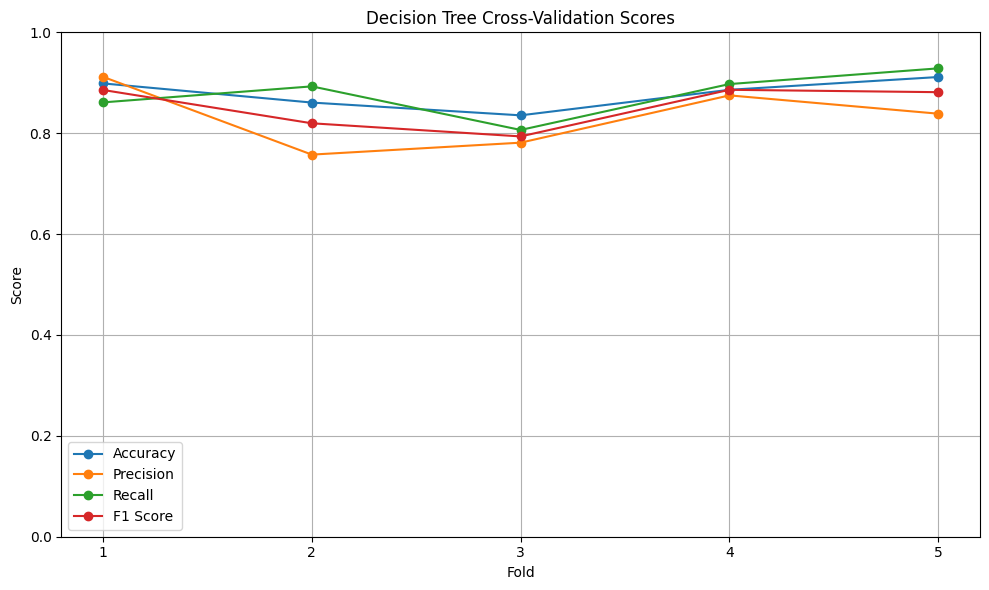

In [62]:
# Use a line chart to visualize the Accuracy, Precision, Recall, and F1 Score of Decision Tree across cross-validation folds,
# in order to observe model performance and metric trends across different folds.

metrics = {
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
}

plt.figure(figsize=(10, 6))

for name, scores in metrics.items():
    plt.plot(range(1, len(scores) + 1), scores, marker='o', label=name)

plt.xticks(range(1, len(accuracy_scores) + 1))
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Decision Tree Cross-Validation Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

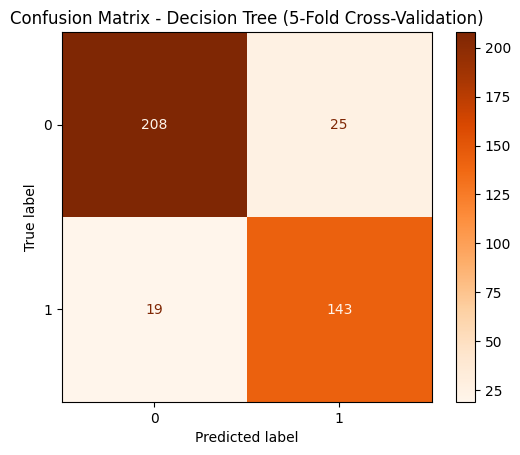

In [63]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get cross-validated predictions for Decision Tree
y_pred_dt = cross_val_predict(decision_tree, X, y, cv=cv)

# Generate confusion matrix
cm_dt = confusion_matrix(y, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=[0, 1])

# Plot confusion matrix
disp_dt.plot(cmap='Oranges')
plt.title('Confusion Matrix - Decision Tree (5-Fold Cross-Validation)')
plt.show()

# **Random Forest**

In [64]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, KFold

# Define the features (attributes) and the target (label)
X = df_encoded.drop(columns=['pass_fail'])   # Features
y = df_encoded['pass_fail']                  # Target (label)

# Create the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Set up 5-fold cross-validation with shuffling
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(rf_model, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Extract the metrics for each fold
accuracy_scores = cv_results['test_accuracy']
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']
rf_acc = accuracy_scores

# Display the scores for each fold
print("Accuracy scores for each fold:", accuracy_scores)
print("Precision scores for each fold:", precision_scores)
print("Recall scores for each fold:", recall_scores)
print("F1 scores for each fold:", f1_scores)

Accuracy scores for each fold: [0.93670886 0.92405063 0.88607595 0.94936709 0.96202532]
Precision scores for each fold: [0.94285714 0.86666667 0.82352941 0.97297297 0.96296296]
Recall scores for each fold: [0.91666667 0.92857143 0.90322581 0.92307692 0.92857143]
F1 scores for each fold: [0.92957746 0.89655172 0.86153846 0.94736842 0.94545455]


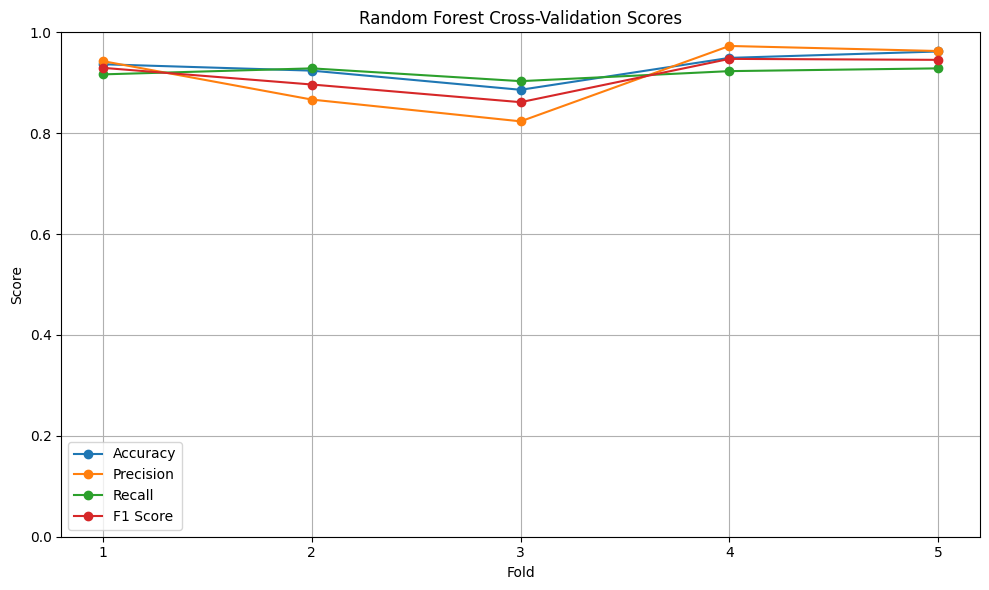

In [65]:
import matplotlib.pyplot as plt

# Use a line chart to visualize the Accuracy, Precision, Recall, and F1 Score of Random Forest across cross-validation folds,
# in order to observe model performance and metric trends across different folds.

metrics = {
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
}

plt.figure(figsize=(10, 6))

for name, scores in metrics.items():
    plt.plot(range(1, len(scores) + 1), scores, marker='o', label=name)

plt.xticks(range(1, len(accuracy_scores) + 1))
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Random Forest Cross-Validation Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

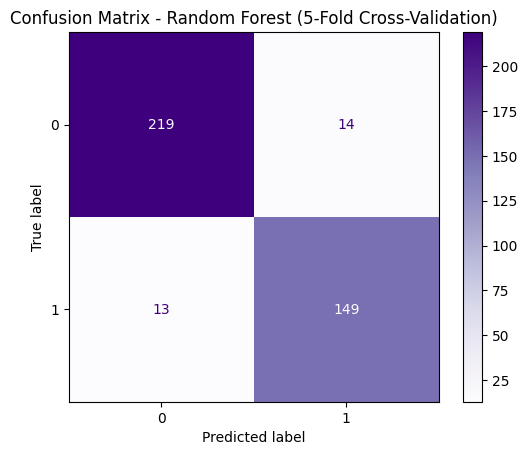

In [66]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get cross-validated predictions for Random Forest
y_pred_rf = cross_val_predict(rf_model, X, y, cv=cv)

# Generate confusion matrix
cm_rf = confusion_matrix(y, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1])

# Plot confusion matrix
disp_rf.plot(cmap='Purples')
plt.title('Confusion Matrix - Random Forest (5-Fold Cross-Validation)')
plt.show()

# **Feature Importance**
# What Drives Student Performance?

This visualization ranks the most important variables used by the Random Forest model to predict student outcomes. The Random Forest model identifies prior academic performance as the strongest predictor of student outcomes. G2 (second-period grade) and G1 (first-period grade) dominate all other features by a large margin, indicating that students’ past performance is the most reliable indicator of final success. While factors such as absences, failures, and family background contributes to the prediction, their impact is significantly smaller. This suggests that early academic performance serves as a powerful early-warning signal for identifying students at risk.

The sharp drop in importance after G1 suggests that most predictive power is concentrated in academic history rather than behavioral or demographic factors.

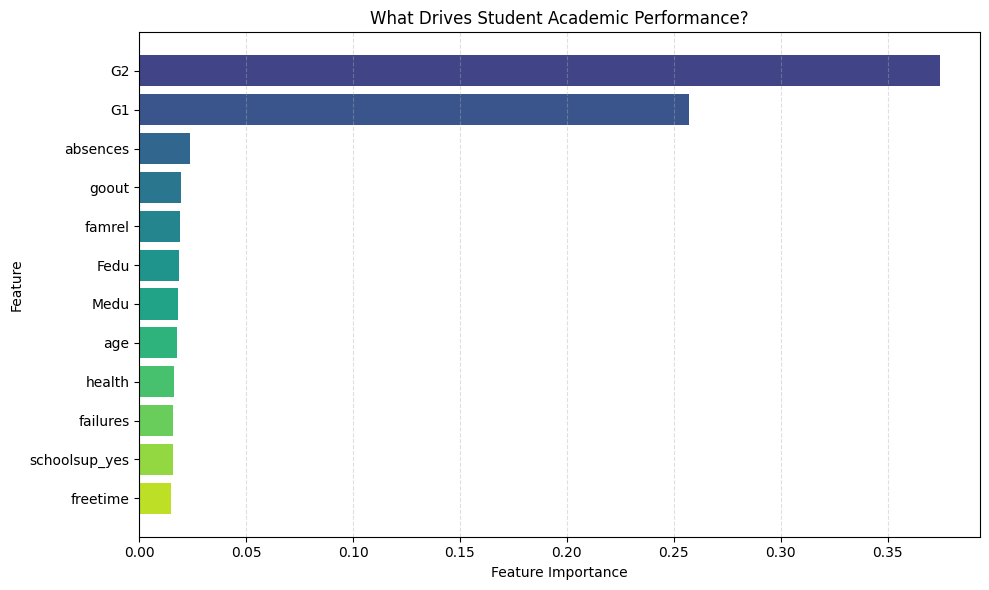

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Fit the Random Forest model to the entire dataset to enable feature importance calculation
rf_model.fit(X, y)

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort and keep top 12
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(12)

# Create viridis colors
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(importance_df)))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1],
    color=colors[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("What Drives Student Academic Performance?")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# **KNN**

In [68]:
# Use a Pipeline with StandardScaler and 5-fold cross-validation to train and evaluate the KNN model,
# in order to measure its Accuracy, Precision, Recall, and F1 Score in the classification task.

from sklearn.model_selection import cross_validate, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define the features (attributes) and the target (label)
X = df_encoded.drop(columns=['pass_fail'])   # Features
y = df_encoded['pass_fail']                  # Target (label)

# Create a pipeline: scaling + KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

# Set up 5-fold cross-validation with shuffling
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform 5-fold cross-validation and get scores for each fold
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(knn_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Extract the metrics for each fold
accuracy_scores = cv_results['test_accuracy']
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']

# Display the scores for each fold
print("Accuracy scores for each fold:", accuracy_scores)
print("Precision scores for each fold:", precision_scores)
print("Recall scores for each fold:", recall_scores)
print("F1 scores for each fold:", f1_scores)

Accuracy scores for each fold: [0.75949367 0.7721519  0.73417722 0.74683544 0.79746835]
Precision scores for each fold: [0.84       0.66666667 0.69230769 0.78787879 0.71428571]
Recall scores for each fold: [0.58333333 0.71428571 0.58064516 0.66666667 0.71428571]
F1 scores for each fold: [0.68852459 0.68965517 0.63157895 0.72222222 0.71428571]


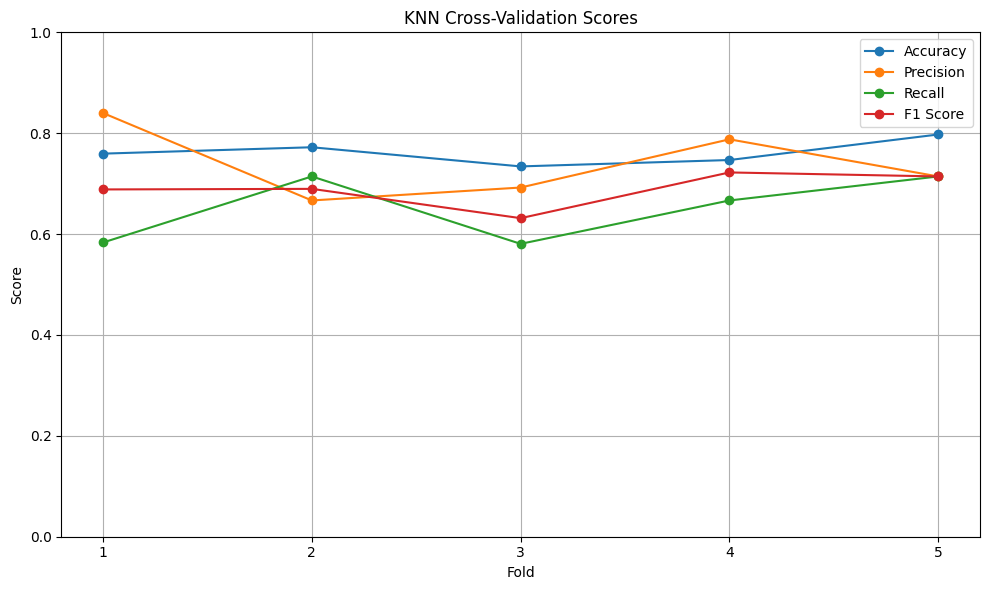

In [69]:
# Use a line chart to visualize the Accuracy, Precision, Recall, and F1 Score of KNN across cross-validation folds,
# in order to observe model performance and metric trends across different folds.

metrics = {
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
}

plt.figure(figsize=(10, 6))

for name, scores in metrics.items():
    plt.plot(range(1, len(scores)+1), scores, marker='o', label=name)

plt.xticks(range(1, len(accuracy_scores)+1))
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('KNN Cross-Validation Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

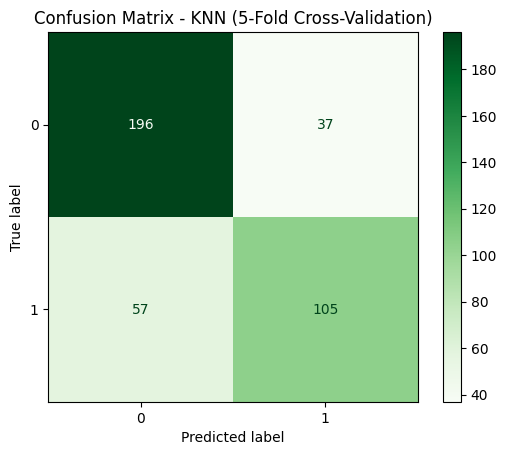

In [70]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get cross-validated predictions for KNN
y_pred_knn = cross_val_predict(knn_pipeline, X, y, cv=cv)

# Generate confusion matrix
cm_knn = confusion_matrix(y, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0, 1])

# Plot confusion matrix
disp_knn.plot(cmap='Greens')
plt.title('Confusion Matrix - KNN (5-Fold Cross-Validation)')
plt.show()

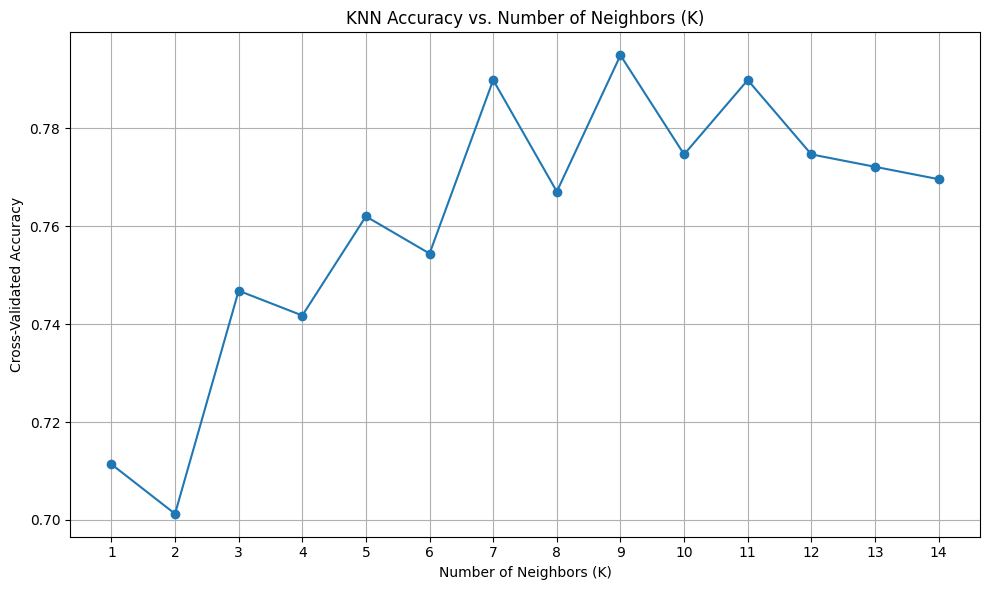

The optimal number of neighbors (K) is: 9
Best cross-validated accuracy: 0.7949


In [71]:
# Compare cross-validated accuracy across different values of K
# to select the optimal number of neighbors for the KNN model and achieve better classification performance.

from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Define the features (attributes) and the target (label)
X = df_encoded.drop(columns=['pass_fail'])   # Features
y = df_encoded['pass_fail']                  # Target (label)

# List to store cross-validation scores for different K values
k_scores = []

# Range of K values to test
k_range = range(1, 15)

# Set up 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Test each K value
for k in k_range:
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(knn_pipeline, X, y, cv=cv, scoring='accuracy')
    k_scores.append(scores.mean())

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Accuracy vs. Number of Neighbors (K)')
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.show()

# Find the optimal K
optimal_k_index = k_scores.index(max(k_scores))
optimal_k = list(k_range)[optimal_k_index]

print(f"The optimal number of neighbors (K) is: {optimal_k}")
print(f"Best cross-validated accuracy: {max(k_scores):.4f}")

# **Perceptron**

In [72]:
# Perceptron
from sklearn.linear_model import Perceptron
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

perceptron_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Perceptron())
])

cv_results = cross_validate(perceptron_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Extract the metrics for each fold
accuracy_scores = cv_results['test_accuracy']
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']

# Display the scores for each fold
print("Accuracy scores for each fold:", accuracy_scores)
print("Precision scores for each fold:", precision_scores)
print("Recall scores for each fold:", recall_scores)
print("F1 scores for each fold:", f1_scores)

Accuracy scores for each fold: [0.87341772 0.82278481 0.82278481 0.87341772 0.92405063]
Precision scores for each fold: [0.93333333 0.73333333 0.77419355 0.87179487 0.86666667]
Recall scores for each fold: [0.77777778 0.78571429 0.77419355 0.87179487 0.92857143]
F1 scores for each fold: [0.84848485 0.75862069 0.77419355 0.87179487 0.89655172]


# **Support Vector Classifier**

In [73]:
# Support Vector Classifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

# Create pipeline: scaling + SVC
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='poly', degree=3))
])

# Perform cross-validation
cv_results = cross_validate(svm_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Extract and print the metrics
accuracy_scores = cv_results['test_accuracy']
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']

print("Accuracy scores for each fold:", accuracy_scores)
print("Precision scores for each fold:", precision_scores)
print("Recall scores for each fold:", recall_scores)
print("F1 scores for each fold:", f1_scores)

Accuracy scores for each fold: [0.82278481 0.79746835 0.7721519  0.72151899 0.83544304]
Precision scores for each fold: [1.         0.77272727 0.88235294 1.         0.89473684]
Recall scores for each fold: [0.61111111 0.60714286 0.48387097 0.43589744 0.60714286]
F1 scores for each fold: [0.75862069 0.68       0.625      0.60714286 0.72340426]


# **Gaussian Naive Bayes**

Gaussian Naive Bayes generally does not require scaling because it is neither distance-based nor gradient-based; instead, it models each feature using class-specific probability distributions, so it is usually not sensitive to feature scale.

In [74]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Perform cross-validation
cv_results = cross_validate(nb_model, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Extract and print the metrics
accuracy_scores = cv_results['test_accuracy']
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']

print("Accuracy scores for each fold:", accuracy_scores)
print("Precision scores for each fold:", precision_scores)
print("Recall scores for each fold:", recall_scores)
print("F1 scores for each fold:", f1_scores)


Accuracy scores for each fold: [0.84810127 0.78481013 0.82278481 0.72151899 0.82278481]
Precision scores for each fold: [0.83333333 0.65714286 0.77419355 0.70731707 0.71875   ]
Recall scores for each fold: [0.83333333 0.82142857 0.77419355 0.74358974 0.82142857]
F1 scores for each fold: [0.83333333 0.73015873 0.77419355 0.725      0.76666667]


# **Multi-Layer Perceptron**

In [75]:
# Multi-Layer Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create pipeline: scaling + MLP
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
])

# Perform cross-validation
cv_results = cross_validate(mlp_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Extract and print the metrics
accuracy_scores = cv_results['test_accuracy']
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']
mlp_acc = accuracy_scores

print("Accuracy scores for each fold:", accuracy_scores)
print("Precision scores for each fold:", precision_scores)
print("Recall scores for each fold:", recall_scores)
print("F1 scores for each fold:", f1_scores)


Accuracy scores for each fold: [0.88607595 0.87341772 0.86075949 0.87341772 0.88607595]
Precision scores for each fold: [0.93548387 0.8        0.85714286 0.91428571 0.80645161]
Recall scores for each fold: [0.80555556 0.85714286 0.77419355 0.82051282 0.89285714]
F1 scores for each fold: [0.86567164 0.82758621 0.81355932 0.86486486 0.84745763]


# **Agglomerative Clustering**

Cluster labels for each sample: [1 2 0 2 2 2 2 1 2 2 1 2 2 2 2 2 2 2 0 2 2 1 2 0 1 0 2 0 2 1 2 2 2 2 2 2 2
 1 1 2 2 0 1 2 2 2 2 2 2 1 2 2 1 2 2 2 2 1 2 2 1 0 2 1 2 2 0 2 2 2 2 2 0 0
 0 2 2 2 0 2 2 2 2 2 2 0 2 2 2 1 2 2 2 2 1 2 2 2 2 2 0 1 2 2 2 1 2 2 0 1 1
 2 2 2 2 1 1 2 0 2 2 2 1 2 2 2 2 0 0 1 1 2 2 2 1 2 0 0 0 1 2 0 2 2 0 2 0 2
 1 0 0 0 0 0 1 2 0 0 0 0 0 0 0 0 0 0 0 2 2 1 0 2 2 0 2 2 2 2 0 2 2 2 2 0 2
 0 0 2 2 0 2 2 0 0 2 2 1 2 1 1 2 2 2 0 2 0 0 0 2 2 0 0 2 0 2 2 0 1 2 2 2 0
 1 0 2 0 2 2 0 2 2 0 1 2 2 2 0 2 0 0 2 2 2 2 0 2 2 0 0 0 0 0 0 0 0 2 2 2 2
 2 2 2 0 0 2 2 0 2 2 0 0 0 2 0 1 2 0 2 1 2 0 2 2 2 2 2 0 2 2 1 2 2 2 2 2 2
 0 0 2 1 2 1 2 1 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 2 2 2 2 0 2 2 0 0 2 1 0 2 2
 0 0 2 0 2 2 2 0 2 2 2 2 0 2 2 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 2 0 0 2 0 0 1 0 2 0 0 0 2 0 2 0 0 0 0 0 0]


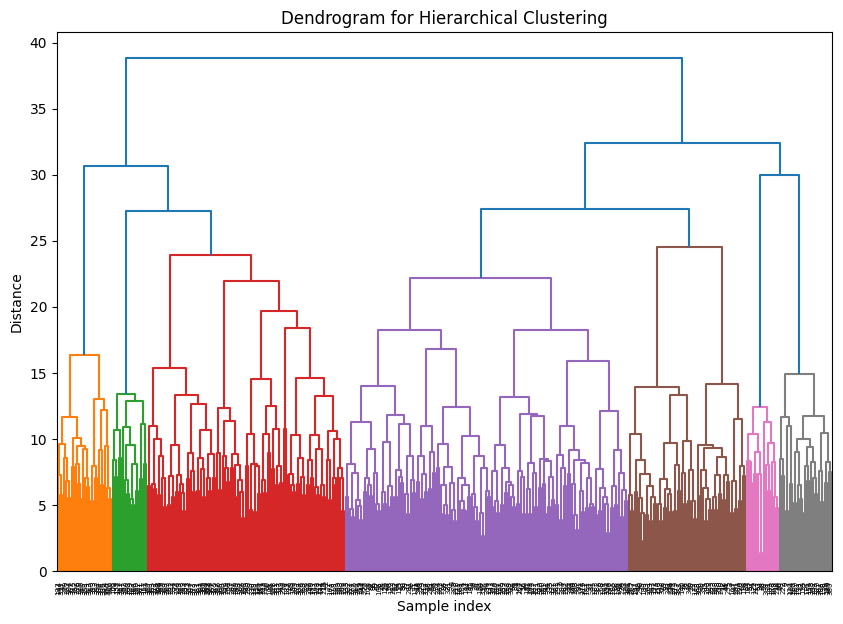

In [76]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Set up and fit the hierarchical clustering model
n_clusters = 3
hierarchical_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = hierarchical_clustering.fit_predict(X_scaled)

# Display the cluster labels
print("Cluster labels for each sample:", cluster_labels)

# Plot the dendrogram
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()


# **KMeans Clustering**

In [77]:
# KMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Set up the K-means model
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit the model and predict cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Display the cluster labels
print("Cluster labels for each sample:", cluster_labels)

# Display the cluster centers
print("Cluster centers:")
print(kmeans.cluster_centers_)


Cluster labels for each sample: [2 2 1 0 2 0 2 2 0 0 0 2 0 0 2 0 0 2 1 0 0 0 0 2 0 1 2 0 0 0 0 0 0 2 2 2 0
 0 0 2 2 0 0 0 2 2 2 0 0 0 0 0 1 0 2 2 0 0 2 0 0 1 2 0 0 0 0 2 0 2 2 2 2 2
 2 0 2 2 1 2 2 2 2 0 2 0 2 2 2 0 2 0 2 0 0 2 0 2 2 2 1 0 0 2 0 2 2 0 2 0 0
 2 2 0 0 0 0 0 2 2 2 0 0 0 2 0 2 1 1 0 0 2 2 0 0 0 1 2 1 0 0 1 0 2 1 2 0 2
 0 1 1 1 0 1 0 2 2 1 2 1 1 2 1 1 1 1 1 0 2 0 1 2 0 1 2 0 2 2 0 2 0 0 0 2 2
 0 0 2 2 2 0 2 1 0 2 0 0 0 0 0 0 2 2 2 0 0 1 0 2 0 2 0 2 1 0 2 2 1 2 2 2 2
 0 1 0 2 2 0 1 2 0 2 0 0 2 2 1 2 2 1 0 0 0 0 2 2 2 1 1 2 1 2 1 2 1 1 0 0 2
 0 0 0 2 2 0 0 1 0 0 2 1 0 2 2 0 2 2 0 0 0 1 1 2 2 2 2 0 0 0 0 0 0 2 2 0 0
 0 2 2 0 0 0 2 0 2 0 1 0 1 2 1 2 1 2 2 2 2 2 0 0 0 2 0 0 2 2 1 1 0 0 2 2 0
 2 2 0 1 2 0 2 1 0 0 2 2 2 0 0 0 1 1 0 1 1 0 0 0 2 1 2 2 1 0 0 2 1 0 2 0 0
 1 1 2 2 2 2 2 0 2 2 0 1 2 1 1 2 0 1 0 2 1 1 1 1 1]
Cluster centers:
[[-0.23617914  0.67285302  0.67717244 -0.21345898  0.07916388 -0.3209451
   0.00870107 -0.0259245  -0.09790798 -0.07625674 -0.10064999  0.05783054
  

# **Early Warning Pattern: Risk relationship plot**
**Do students with more absences and lower prior scores cluster in the fail group?**


This visualization shows the relationship between student absences and prior academic performance (G2), with outcomes categorized as pass or fail. A clear pattern emerges where students with lower G2 scores are more likely to fall into the fail category, regardless of absences. While absences contribute to risk, they are not sufficient alone. The combination of low prior performance and higher absences creates a stronger early-warning signal for identifying at-risk students.


Above ~12 (G2 ≥ 12) = almost all are Pass (blue),
Below ~10 (G2 ≤ 10) = mostly Fail (orange)


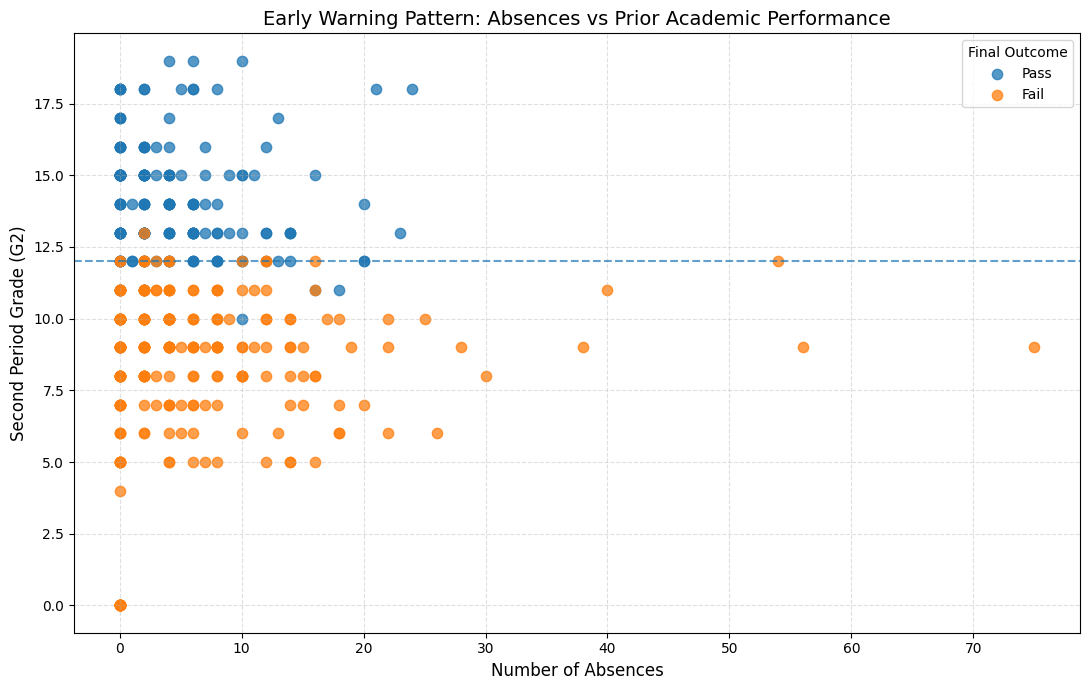

In [78]:
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["Outcome"] = plot_df["pass_fail"].map({0: "Fail", 1: "Pass"})

pass_df = plot_df[plot_df["Outcome"] == "Pass"]
fail_df = plot_df[plot_df["Outcome"] == "Fail"]

plt.figure(figsize=(11, 7))

plt.scatter(pass_df["absences"], pass_df["G2"], alpha=0.75, s=55, label="Pass")
plt.scatter(fail_df["absences"], fail_df["G2"], alpha=0.75, s=55, label="Fail")

plt.xlabel("Number of Absences", fontsize=12)
plt.ylabel("Second Period Grade (G2)", fontsize=12)
plt.title("Early Warning Pattern: Absences vs Prior Academic Performance", fontsize=14)
plt.legend(title="Final Outcome")
plt.grid(True, linestyle="--", alpha=0.4)
plt.axhline(y=12, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Study Behavior vs Outcome**
**Do students who study more and have fewer past failures perform better?**

Students who failed tend to have a higher number of past failures and slightly lower study time compared to those who passed. The difference in past failures is much more pronounced, indicating that academic history is a stronger predictor of performance than study effort alone. While increased study time is associated with better outcomes, it is not sufficient by itself to guarantee success.

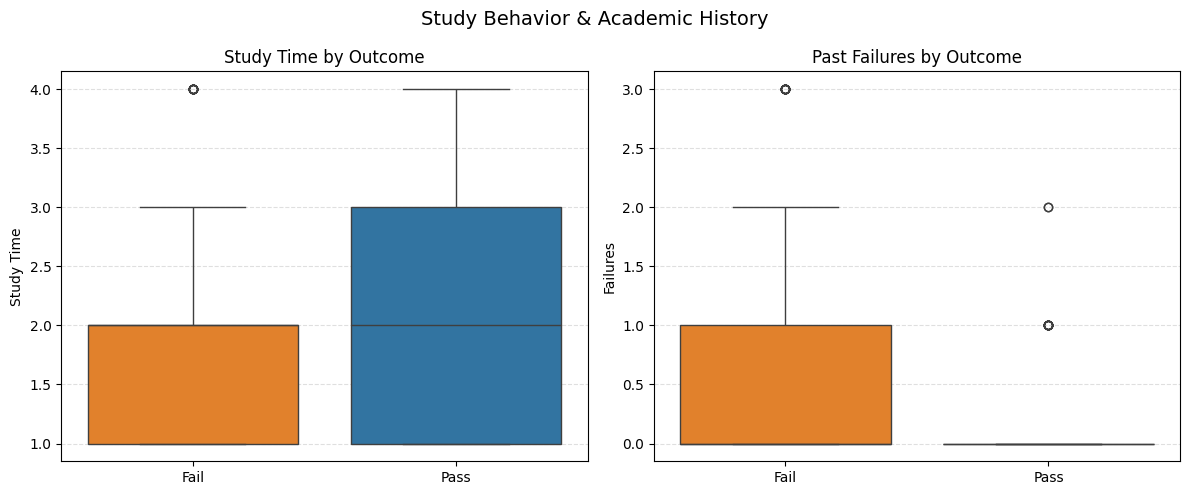

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["Outcome"] = plot_df["pass_fail"].map({0: "Fail", 1: "Pass"})

# Define consistent colors
palette = ["#ff7f0e", "#1f77b4"]  # Fail, Pass

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Study Time
sns.boxplot(x="Outcome", y="studytime", data=plot_df, ax=axes[0], hue=df['pass_fail'].map({0: 'Fail', 1: 'Pass'}), palette=palette)
axes[0].set_title("Study Time by Outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("Study Time")
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Plot 2: Failures
sns.boxplot(x="Outcome", y="failures", data=plot_df, ax=axes[1], hue=df['pass_fail'].map({0: 'Fail', 1: 'Pass'}), palette=palette)
axes[1].set_title("Past Failures by Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("Failures")
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("Study Behavior & Academic History", fontsize=14)
plt.tight_layout()
plt.show()

# **Risk Heatmap (Group Patterns)**

These heatmaps present a group-level early warning view by showing both the probability of passing and the risk of failure based on study time and prior failures. A clear pattern emerges: students with no prior failures maintain relatively higher chances of passing, while even one past failure significantly increases failure risk. As the number of past failures increases, the likelihood of passing drops sharply and failure risk approaches its highest levels, regardless of study time.

Although increased study time provides some improvement, it is not sufficient to overcome the impact of prior failures. This highlights that academic history is the dominant factor in determining risk, and students with repeated failures should be prioritized for early intervention.

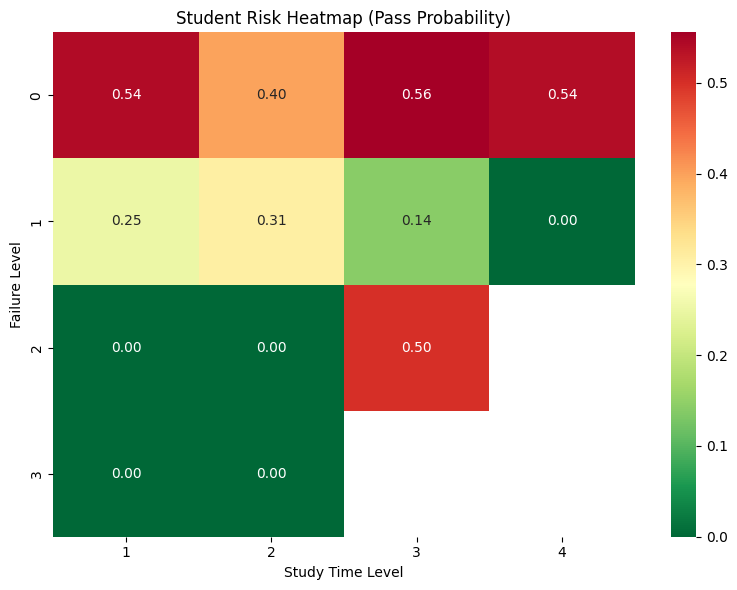

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy
heat_df = df.copy()

# Create grouping labels
heat_df["Study_Level"] = heat_df["studytime"]
heat_df["Failure_Level"] = heat_df["failures"]

# Group and compute averages
grouped = heat_df.groupby(["Study_Level", "Failure_Level"])[
    ["G1", "G2", "absences", "pass_fail"]
].mean().reset_index()

# Pivot for heatmap (use pass_fail as main risk indicator)
heatmap_data = grouped.pivot(
    index="Failure_Level",
    columns="Study_Level",
    values="pass_fail"
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn_r")

plt.title("Student Risk Heatmap (Pass Probability)")
plt.xlabel("Study Time Level")
plt.ylabel("Failure Level")

plt.tight_layout()
plt.show()

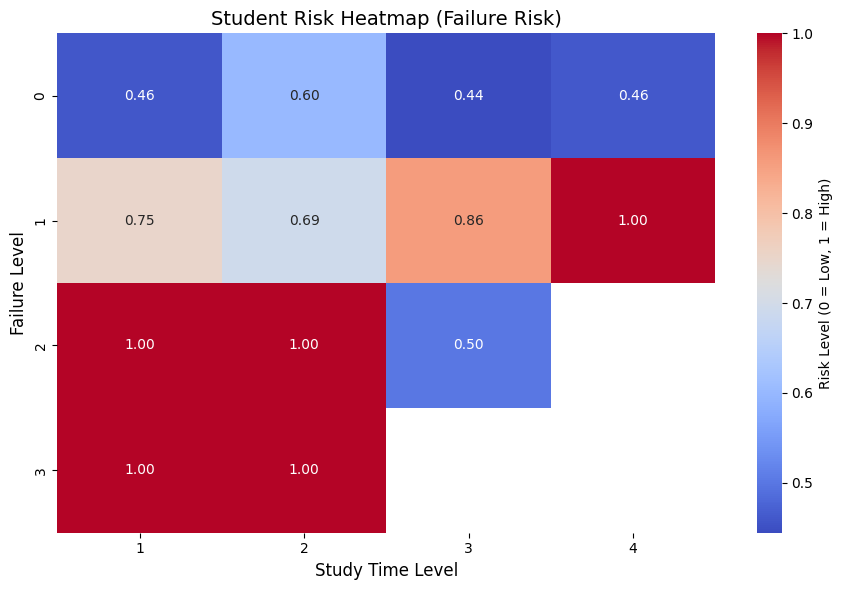

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy of the dataset
heat_df = df.copy()

# Create grouped labels
heat_df["Study_Level"] = heat_df["studytime"]
heat_df["Failure_Level"] = heat_df["failures"]

# Convert pass probability to failure risk
# pass_fail: 1 = Pass, 0 = Fail
# risk: 0 = Low Risk, 1 = High Risk
heat_df["risk"] = 1 - heat_df["pass_fail"]

# Group by study level and failure level, then calculate average risk
grouped = heat_df.groupby(["Failure_Level", "Study_Level"])[
    ["risk", "G1", "G2", "absences"]
].mean().reset_index()

# Pivot for heatmap
heatmap_data = grouped.pivot(
    index="Failure_Level",
    columns="Study_Level",
    values="risk"
)

# Plot heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",   # blue = low risk, red = high risk
    cbar_kws={"label": "Risk Level (0 = Low, 1 = High)"}
)

plt.title("Student Risk Heatmap (Failure Risk)", fontsize=14)
plt.xlabel("Study Time Level", fontsize=12)
plt.ylabel("Failure Level", fontsize=12)
plt.tight_layout()
plt.show()

# **Model Confidence: Predicted Pass vs Fail Risk**

This visualization shows the model’s average predicted probabilities for students classified as pass or fail. A clear separation is observed, where students predicted to fail have a very high fail probability, while those predicted to pass have a very high pass probability. The minimal overlap between the two groups indicates that the model makes confident and reliable predictions. This confirms that the model is not only accurate in classification but also provides strong confidence-based early-warning signals, enabling educators to identify at-risk students and intervene with greater certainty.

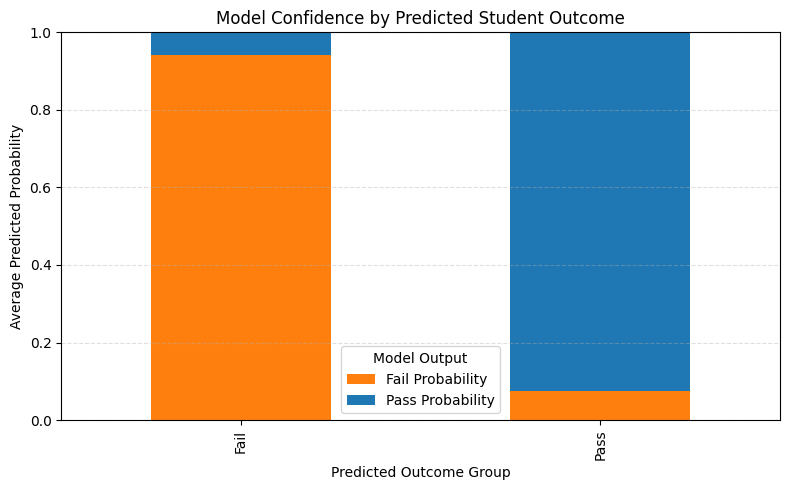

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = rf_model.predict_proba(X)

# Build results dataframe
prob_df = pd.DataFrame({
    "Actual": y.values,
    "Predicted": rf_model.predict(X),
    "Prob_Fail": y_prob[:, 0],
    "Prob_Pass": y_prob[:, 1]
})

# Map labels for readability
prob_df["Predicted_Label"] = prob_df["Predicted"].map({0: "Fail", 1: "Pass"})

# Average predicted probabilities by predicted class
grouped_probs = prob_df.groupby("Predicted_Label")[["Prob_Fail", "Prob_Pass"]].mean()

# Reorder rows
grouped_probs = grouped_probs.reindex(["Fail", "Pass"])

# Plot stacked bar chart
ax = grouped_probs.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#ff7f0e", "#1f77b4"]   # Fail = orange, Pass = blue
)

plt.title("Model Confidence by Predicted Student Outcome")
plt.xlabel("Predicted Outcome Group")
plt.ylabel("Average Predicted Probability")
plt.legend(["Fail Probability", "Pass Probability"], title="Model Output")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# **Comparison for 3 selected models**

This section compares the top three performing models: Logistic Regression, Decision Tree, and Random Forest, using 5-fold cross-validation. The boxplots show how each model performs across different data splits, highlighting both accuracy and variability.

From the results, Random Forest achieves the highest accuracy and shows strong consistency across folds, making it the most reliable model. Logistic Regression and Decision Tree also perform well, but with slightly lower accuracy and more variation.

In [83]:
import numpy as np
import pandas as pd

model_results = {
    "Logistic Regression": logreg_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc
}

summary = pd.DataFrame({
    "Model": model_results.keys(),
    "Mean Accuracy": [np.mean(scores) for scores in model_results.values()],
    "Std Dev": [np.std(scores) for scores in model_results.values()]
})

print(summary)

                 Model  Mean Accuracy   Std Dev
0  Logistic Regression       0.883544  0.025818
1        Decision Tree       0.878481  0.027267
2        Random Forest       0.931646  0.026065


/tmp/ipykernel_3792/1711635051.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[0].boxplot(score_lists, patch_artist=True, labels=model_names)


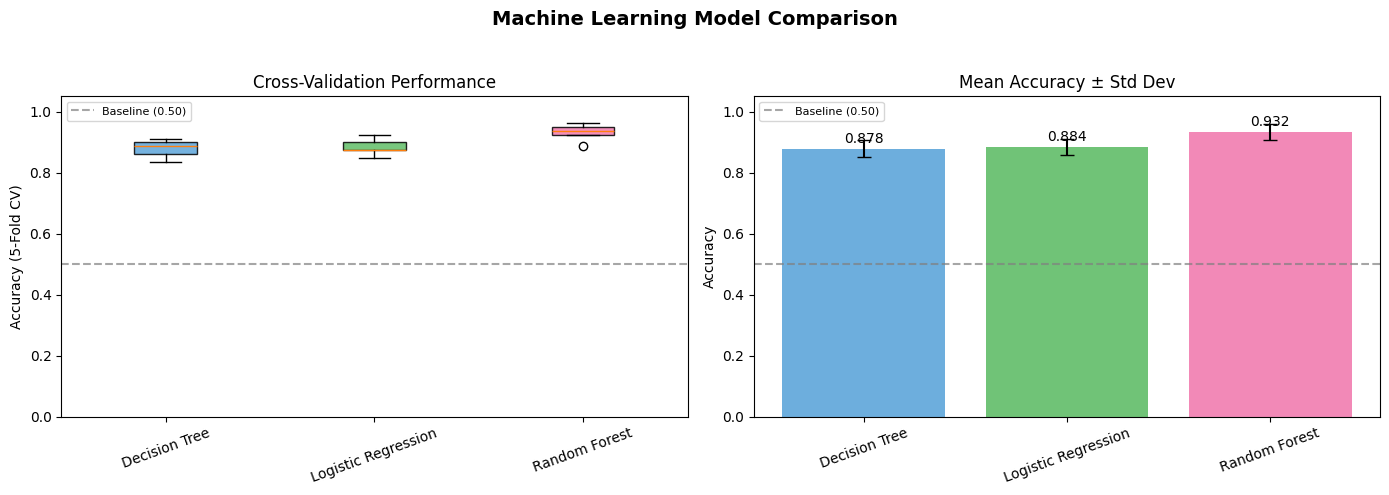

In [84]:
import numpy as np
import matplotlib.pyplot as plt

model_scores = {
    "Decision Tree": dt_acc,
    "Logistic Regression": logreg_acc,
    "Random Forest": rf_acc
}

model_names = list(model_scores.keys())
score_lists = [model_scores[name] for name in model_names]

means = [np.mean(scores) for scores in score_lists]
stds = [np.std(scores) for scores in score_lists]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

box = axes[0].boxplot(score_lists, patch_artist=True, labels=model_names)
box_colors = ['#5DA5DA', '#60BD68', '#F17CB0']

for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

axes[0].axhline(y=0.5, linestyle='--', color='gray', alpha=0.7, label='Baseline (0.50)')
axes[0].set_title("Cross-Validation Performance", fontsize=12)
axes[0].set_ylabel("Accuracy (5-Fold CV)")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(loc='upper left', fontsize=8)

bars = axes[1].bar(model_names, means, yerr=stds, capsize=5,
                   color=box_colors, alpha=0.9)

axes[1].axhline(y=0.5, linestyle='--', color='gray', alpha=0.7, label='Baseline (0.50)')
axes[1].set_title("Mean Accuracy ± Std Dev", fontsize=12)
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(loc='upper left', fontsize=8)

for i, mean_val in enumerate(means):
    axes[1].text(i, mean_val + 0.02, f"{mean_val:.3f}", ha='center', fontsize=10)

fig.suptitle("Machine Learning Model Comparison", fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()